In [11]:
from helper_PP_GP import prepare_data_from_parquet, train_model, compute_meta, plot_pp_overview, evaluate_test_metrics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
np.random.seed(0)

In [13]:
parquet_path = "../data/processed/cpr_gfw_2024.parquet"   # change to your path
train_coords, train_covs, train_y, test_coords, test_covs, test_y, scalers, df = prepare_data_from_parquet(parquet_path)
meta = compute_meta(df)

In [14]:
print("N train:", train_coords.shape[0],
      "\ncoord_dim:", train_coords.shape[1],
      "\nn_covs:", train_covs.shape[1],
      "\ny_dim:", (train_y.shape[1] if train_y.ndim > 1 else 1))

assert train_coords.shape[0] == train_covs.shape[0] == train_y.shape[0]
assert test_coords.shape[0]  == test_covs.shape[0]  == test_y.shape[0]


N train: 16121 
coord_dim: 3 
n_covs: 2 
y_dim: 1


In [15]:
# train
model, losses = train_model(train_coords, train_covs, train_y,
                            M=300,       # inducing points
                            lr=1e-3,
                            num_steps=1000,
                            minibatch = min(1024, train_coords.shape[0]),
                            device="cpu"
                            )  # or "cuda" if available

9517.1846
8733.7676
9394.3252
7789.1021
8314.8682
7023.2949
7707.5605
6669.8652
6684.1431
6388.1924
6572.7988
6592.8818
5962.4531
7142.6748
6138.3677
5539.0957
7168.8823
5647.8545
6516.5088
6194.4531
6292.3267


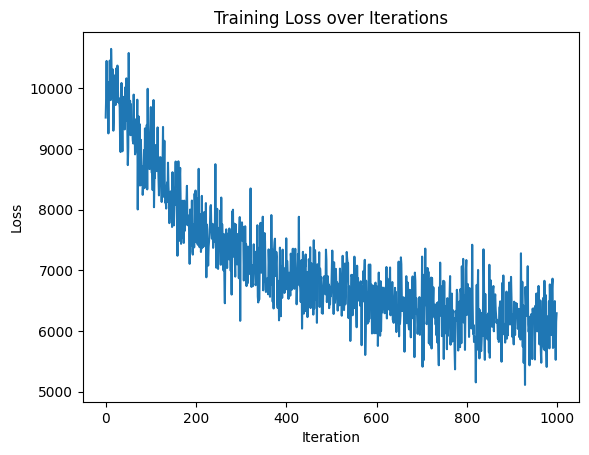

In [16]:
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss over Iterations")
plt.show()

In [17]:
# Merge train and test
all_coords = np.vstack([train_coords, test_coords])
all_covs = np.vstack([train_covs, test_covs])
all_y = np.concatenate([train_y, test_y])

# Sort by time (3rd column)
sort_idx = np.argsort(all_coords[:, 2])
all_coords_sorted = all_coords[sort_idx]
all_covs_sorted = all_covs[sort_idx]
all_y_sorted = all_y[sort_idx]
rate_mean, rate_p05, rate_p95 = model.predict_rate(all_coords_sorted, all_covs_sorted, num_samples=200)


In [18]:
# Convert test_coords[:,2] (normalized time) back to datetime
t_norm_test = test_coords[:, 2]
test_dates = pd.to_datetime(meta["t_min"]) + pd.to_timedelta(
    t_norm_test * (meta["t_max"] - meta["t_min"])
)

# Pick a random date from test_dates
rng = np.random.default_rng()
target_np = rng.choice(test_dates)  # numpy.datetime64
target_date = pd.to_datetime(target_np).date() # convert to datetime.date

print("Randomly chosen test date:", target_date)

Randomly chosen test date: 2025-08-08


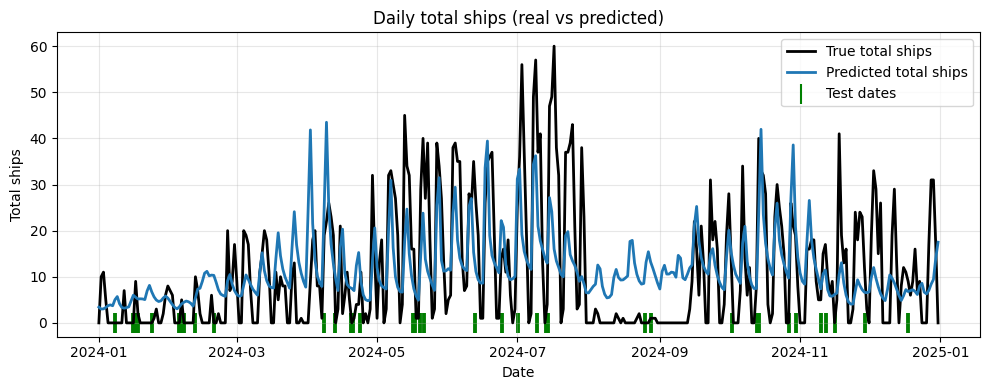

Selected closest available date: 2025-08-08 (normalized 1.604)


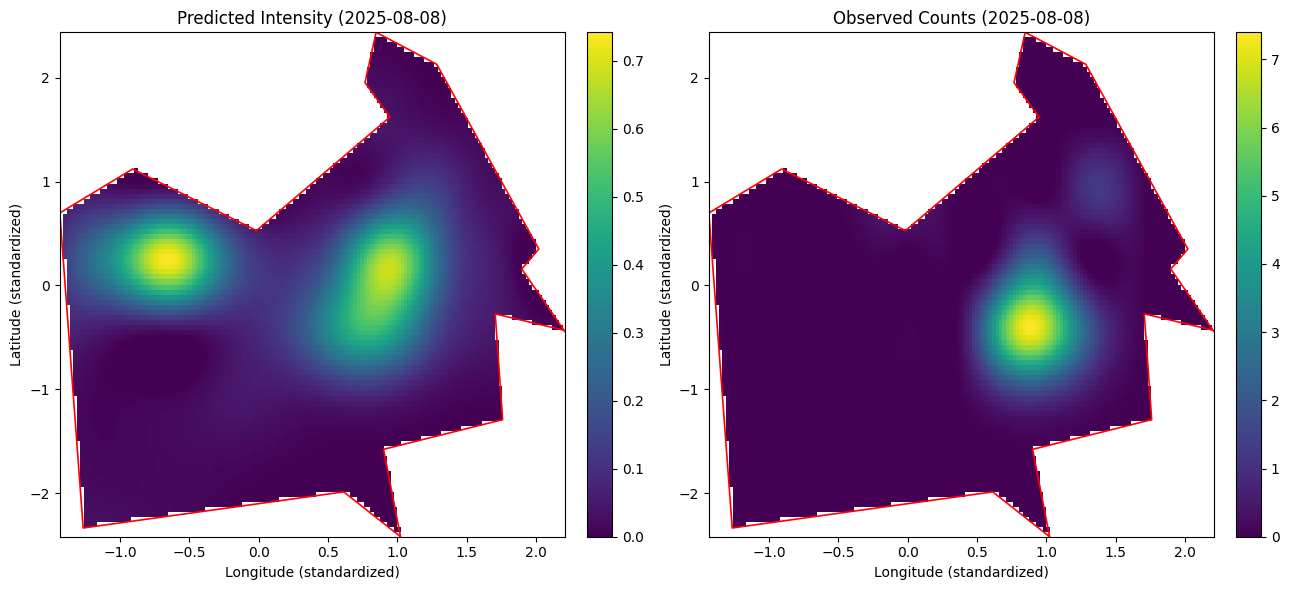

In [19]:
# Example usage
plot_pp_overview(
    model, 
    df,
    all_coords_sorted, 
    all_covs_sorted, 
    y_true=all_y_sorted, 
    meta=meta, 
    num_samples=800, 
    target_date=target_date,
    test_coords = test_coords,
    t_scaler = scalers["t_scaler"]
)


In [20]:
rate_mean_test, rate_p05_test, rate_p95_test = model.predict_rate(test_coords, test_covs, num_samples=200)

metrics = evaluate_test_metrics(test_y, rate_mean_test,test_dates)
print("Mean log-likelihood (per obs):", metrics["mean_ll_obs"])
print("Daily RMSE:", metrics["rmse_daily"])
print("Daily mean log-likelihood:", metrics["mean_ll_daily"])

Mean log-likelihood (per obs): -0.4527538590963579
Daily RMSE: 8.64852058215509
Daily mean log-likelihood: -5.296093021718147
